In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

C:\Users\Dhruvi\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Dhruvi\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


In [3]:
df = pd.read_csv("crime_dataset_india.csv")

In [4]:
df.head()

,Report Number,Date Reported,Date of Occurrence,Time of Occurrence,City,Crime Code,Crime Description,Victim Age,Victim Gender,Weapon Used,Crime Domain,Police Deployed,Case Closed,Date Case Closed
0,1,02-01-2020 00:00,01-01-2020 00:00,01-01-2020 01:11,Ahmedabad,576,IDENTITY THEFT,16,M,Blunt Object,Violent Crime,13,No,NaN
1,2,01-01-2020 19:00,01-01-2020 01:00,01-01-2020 06:26,Chennai,128,HOMICIDE,37,M,Poison,Other Crime,9,No,NaN
2,3,02-01-2020 05:00,01-01-2020 02:00,01-01-2020 14:30,Ludhiana,271,KIDNAPPING,48,F,Blunt Object,Other Crime,15,No,NaN
3,4,01-01-2020 05:00,01-01-2020 03:00,01-01-2020 14:46,Pune,170,BURGLARY,49,F,Firearm,Other Crime,1,Yes,29-04-2020 05:00
4,5,01-01-2020 21:00,01-01-2020 04:00,01-01-2020 16:51,Pune,421,VANDALISM,30,F,Other,Other Crime,18,Yes,08-01-2020 21:00


In [5]:
df.shape

(40160, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40160 entries, 0 to 40159
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Report Number       40160 non-null  int64 
 1   Date Reported       40160 non-null  object
 2   Date of Occurrence  40160 non-null  object
 3   Time of Occurrence  40160 non-null  object
 4   City                40160 non-null  object
 5   Crime Code          40160 non-null  int64 
 6   Crime Description   40160 non-null  object
 7   Victim Age          40160 non-null  int64 
 8   Victim Gender       40160 non-null  object
 9   Weapon Used         34370 non-null  object
 10  Crime Domain        40160 non-null  object
 11  Police Deployed     40160 non-null  int64 
 12  Case Closed         40160 non-null  object
 13  Date Case Closed    20062 non-null  object
dtypes: int64(4), object(10)
memory usage: 4.3+ MB


In [7]:
df.columns

Index(['Report Number', 'Date Reported', 'Date of Occurrence',
       'Time of Occurrence', 'City', 'Crime Code', 'Crime Description',
       'Victim Age', 'Victim Gender', 'Weapon Used', 'Crime Domain',
       'Police Deployed', 'Case Closed', 'Date Case Closed'],
      dtype='object')

In [8]:
df.isnull().sum()

Report Number             0
Date Reported             0
Date of Occurrence        0
Time of Occurrence        0
City                      0
Crime Code                0
Crime Description         0
Victim Age                0
Victim Gender             0
Weapon Used            5790
Crime Domain              0
Police Deployed           0
Case Closed               0
Date Case Closed      20098
dtype: int64

In [9]:
drop_cols = [
    "Report Number",
    "Date Reported",
    "Date of Occurrence",
    "Time of Occurrence",
    "Crime Code",
    "Crime Description",
    "Date Case Closed"
]

df = df.drop(columns=drop_cols)

df.head()

,City,Victim Age,Victim Gender,Weapon Used,Crime Domain,Police Deployed,Case Closed
0,Ahmedabad,16,M,Blunt Object,Violent Crime,13,No
1,Chennai,37,M,Poison,Other Crime,9,No
2,Ludhiana,48,F,Blunt Object,Other Crime,15,No
3,Pune,49,F,Firearm,Other Crime,1,Yes
4,Pune,30,F,Other,Other Crime,18,Yes


In [10]:
df.columns

Index(['City', 'Victim Age', 'Victim Gender', 'Weapon Used', 'Crime Domain',
       'Police Deployed', 'Case Closed'],
      dtype='object')

In [11]:
df.isnull().sum()

City                  0
Victim Age            0
Victim Gender         0
Weapon Used        5790
Crime Domain          0
Police Deployed       0
Case Closed           0
dtype: int64

In [12]:
df["Victim Age"] = df["Victim Age"].fillna(
    df["Victim Age"].median()
)
df["Police Deployed"] = df["Police Deployed"].fillna(
    df["Police Deployed"].median()
)

In [13]:
print(df["Case Closed"].unique())

['No' 'Yes']


In [14]:
df["Case Closed"] = df["Case Closed"].map({
    "Yes": 1,
    "No": 0
})

In [15]:
df["Case Closed"].head()

0    0
1    0
2    0
3    1
4    1
Name: Case Closed, dtype: int64

In [16]:
df["Weapon Used"] = df["Weapon Used"].notna().astype(int)
df["Weapon Used"].value_counts()

Weapon Used
1    34370
0     5790
Name: count, dtype: int64

In [17]:
city_df = df.groupby("City").agg(
    Total_Crimes=("City", "count"),
    Avg_Victim_Age=("Victim Age", "mean"),
    Avg_Police_Deployed=("Police Deployed", "mean"),
    Weapon_Crime_Rate=("Weapon Used", "mean"),
    Case_Closure_Rate=("Case Closed", "mean")
).reset_index()

city_df.head()

,City,Total_Crimes,Avg_Victim_Age,Avg_Police_Deployed,Weapon_Crime_Rate,Case_Closure_Rate
0,Agra,764,43.691099,10.212042,0.842932,0.492147
1,Ahmedabad,1817,44.319207,10.020914,0.856907,0.511282
2,Bangalore,3588,44.658584,9.952341,0.855630,0.490245
3,Bhopal,690,44.198551,9.889855,0.850725,0.478261
4,Chennai,2493,44.061372,10.235058,0.866025,0.498195


In [18]:
city_df.shape

(29, 6)

In [19]:
X = city_df.drop("City", axis=1)

X.head()

,Total_Crimes,Avg_Victim_Age,Avg_Police_Deployed,Weapon_Crime_Rate,Case_Closure_Rate
0,764,43.691099,10.212042,0.842932,0.492147
1,1817,44.319207,10.020914,0.856907,0.511282
2,3588,44.658584,9.952341,0.855630,0.490245
3,690,44.198551,9.889855,0.850725,0.478261
4,2493,44.061372,10.235058,0.866025,0.498195


In [20]:
X.shape

(29, 5)

In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[-4.82450709e-01, -1.46706427e+00,  1.52338658e+00,
        -1.90136582e+00, -3.10090223e-01],
       [ 3.35845075e-01, -4.62323878e-01,  2.06026004e-01,
         1.24153538e-01,  6.70897483e-01],
       [ 1.71210513e+00,  8.05532388e-02, -2.66612821e-01,
        -6.09488397e-02, -4.07561576e-01],
       [-5.39956775e-01, -6.55330048e-01, -6.97300908e-01,
        -7.71905598e-01, -1.02193780e+00],
       [ 8.61170764e-01, -8.74765502e-01,  1.68202734e+00,
         1.44568294e+00, -2.34559217e-05]])

In [22]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

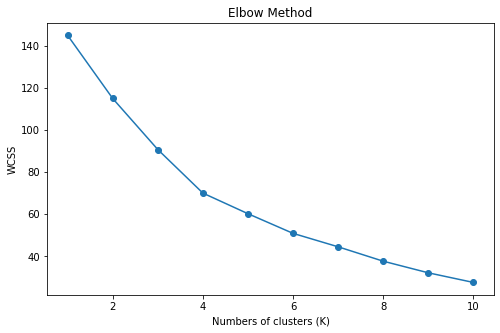

In [23]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("Numbers of clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [24]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

city_df["Cluster"] = kmeans.fit_predict(X_scaled)
city_df[["City", "Cluster"]]

,City,Cluster
0,Agra,3
1,Ahmedabad,1
2,Bangalore,0
3,Bhopal,2
4,Chennai,1
5,Delhi,0
6,Faridabad,2
7,Ghaziabad,3
8,Hyderabad,0
9,Indore,1


In [25]:
city_df.head()

,City,Total_Crimes,Avg_Victim_Age,Avg_Police_Deployed,Weapon_Crime_Rate,Case_Closure_Rate,Cluster
0,Agra,764,43.691099,10.212042,0.842932,0.492147,3
1,Ahmedabad,1817,44.319207,10.020914,0.856907,0.511282,1
2,Bangalore,3588,44.658584,9.952341,0.855630,0.490245,0
3,Bhopal,690,44.198551,9.889855,0.850725,0.478261,2
4,Chennai,2493,44.061372,10.235058,0.866025,0.498195,1


In [26]:
score = silhouette_score(
    X_scaled,
    city_df["Cluster"]
)

print("Silhouette Score:", score)

Silhouette Score: 0.2591293552628389


In [27]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_scaled)

city_df["PCA1"] = pca_data[:, 0]
city_df["PCA2"] = pca_data[:, 1]
city_df.head()

,City,Total_Crimes,Avg_Victim_Age,Avg_Police_Deployed,Weapon_Crime_Rate,Case_Closure_Rate,Cluster,PCA1,PCA2
0,Agra,764,43.691099,10.212042,0.842932,0.492147,3,-2.233729,0.691396
1,Ahmedabad,1817,44.319207,10.020914,0.856907,0.511282,1,0.032333,0.766894
2,Bangalore,3588,44.658584,9.952341,0.855630,0.490245,0,-0.491945,0.510086
3,Bhopal,690,44.198551,9.889855,0.850725,0.478261,2,-1.174494,-1.169859
4,Chennai,2493,44.061372,10.235058,0.866025,0.498195,1,0.039888,1.880931


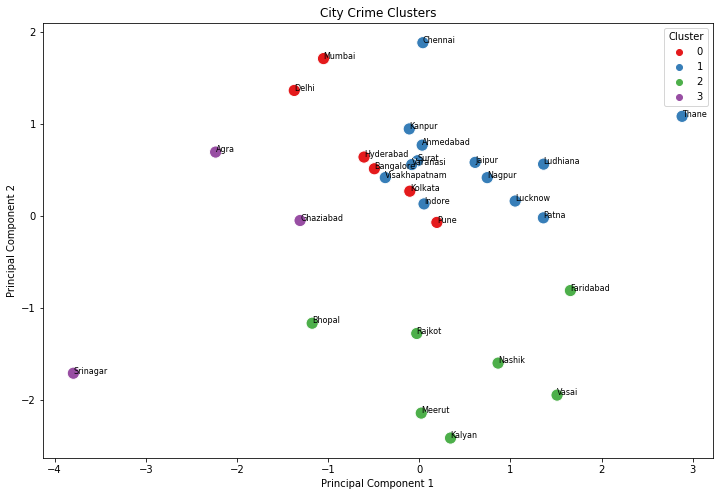

In [28]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=city_df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set1",
    s=150
)

for i in range(len(city_df)):
    plt.text(
        city_df["PCA1"][i],
        city_df["PCA2"][i],
        city_df["City"][i],
        fontsize=8
    )

plt.title("City Crime Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [29]:
cluster_summary = city_df.groupby("Cluster").mean(
    numeric_only=True
)

print(cluster_summary)

         Total_Crimes  Avg_Victim_Age  Avg_Police_Deployed  Weapon_Crime_Rate  \
Cluster                                                                         
0         3502.333333       44.514934             9.960615           0.854143   
1         1112.692308       44.577508            10.074888           0.859963   
2          406.000000       45.044670             9.808965           0.856386   
3          613.000000       43.909559            10.113220           0.842126   

         Case_Closure_Rate      PCA1      PCA2  
Cluster                                         
0                 0.497761 -0.571465  0.734891  
1                 0.509611  0.581887  0.619456  
2                 0.487660  0.457063 -1.626745  
3                 0.474180 -2.445061 -0.358353  


In [34]:
import joblib

joblib.dump(kmeans, "kmeans.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [35]:
city_df.to_csv(
    "city_crime_clusters.csv",
    index=False
)

In [36]:
print(cluster_summary)

         Total_Crimes  Avg_Victim_Age  Avg_Police_Deployed  Weapon_Crime_Rate  \
Cluster                                                                         
0         3502.333333       44.514934             9.960615           0.854143   
1         1112.692308       44.577508            10.074888           0.859963   
2          406.000000       45.044670             9.808965           0.856386   
3          613.000000       43.909559            10.113220           0.842126   

         Case_Closure_Rate      PCA1      PCA2  
Cluster                                         
0                 0.497761 -0.571465  0.734891  
1                 0.509611  0.581887  0.619456  
2                 0.487660  0.457063 -1.626745  
3                 0.474180 -2.445061 -0.358353  


In [37]:
city_df[["City", "Cluster"]]

,City,Cluster
0,Agra,3
1,Ahmedabad,1
2,Bangalore,0
3,Bhopal,2
4,Chennai,1
5,Delhi,0
6,Faridabad,2
7,Ghaziabad,3
8,Hyderabad,0
9,Indore,1
